# Tutorial 01: NVE cavity MD with a single A–A dimer

This notebook sets up the microcanonical (NVE) simulation of a toy molecular dimer, which has partial charges coupled to a cavity-mode particle. We will build the system explicitly so we can see each OpenMM object and its role is visible.

What we will do is as follows:

1. Import the OpenMM cavity-MD extensions and mKA force-field constants
2. Set up the OpenMM `System`, integrator, and initial conditions
3. Run a short MD trajectory and record the molecular dipole $\mathbf{d}(t)$
4. Post-process an IR-style spectrum from that dipole time series

**Kernel:** There's a bit of setup that you need to. If you are working from the repo directly, you can tun the command below to start up a Jupyter lab withe everything installed. 
```bash
pixi run -e test jupyter lab
```
We're using Runpod GPU, which starts its own Jupyter Lab instance. So, you have to make the installed environment into a Jupyter kernel, etc. Don't worry I've fixed that for you. 

### Unit conventions

The mKA parameters are defined in atomic units (Hartree / Bohr / electron mass).
OpenMM stores energies, lengths, and times in kJ/mol, nm, and ps (please be aware of this!). The `Units` helper from `openmm.cavitymd.constants` performs the conversions used below.


## 1. Import the codebase

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import openmm
from openmm import unit

from openmm.cavitymd.constants import Units
from openmm.cavitymd.forcefields.mka import (
    MASS_A, MASS_B, PHOTON_MASS_AMU,
    K_AA_AU, R0_AA_AU, K_BB_AU, R0_BB_AU,
    EPS_AA_AU, SIG_AA_AU, EPS_AB_AU, SIG_AB_AU, EPS_BB_AU, SIG_BB_AU,
    CHARGE_MAG, OMEGA_C_CM1,
)


# Use this commannd for sanity check. Does my system support the platforms I am targeting?
print("OpenMM version:", openmm.__version__)
for i in range(openmm.Platform.getNumPlatforms()):
    print(" platform:", openmm.Platform.getPlatform(i).getName())

OpenMM version: 8.5
 platform: Reference
 platform: CPU
 platform: CUDA


Next, we need to define helper functions. One is for computing the dipole magnitude for a single molecule.

In [2]:
def dipole_magnitude(pos, charges, indices):
    """Translation/rotation-invariant dipole magnitude (|Σ qᵢ rᵢ|)."""
    d = np.dot(charges, pos[indices])
    return np.linalg.norm(d)

AMU_TO_AU_CAVITY = 1822.888486209  # matches CavityForce's internal amu->a.u. mass conversion

## 2. Set simulation parameters

Simulation parameters follow atomic units for the most part, with time following femtosecond unit being the only exception. However, keep in mind that OpenMM operates on different set of units internally. See Section 18.2 in [OpenMM introduction](https://docs.openmm.org/latest/userguide/theory/01_introduction.html)

In [3]:
# ============================================================
# Tunable parameters: change these to explore the physics
# ============================================================
lambda_coupling = 0.5    # cavity coupling λ (a.u.): try 0.0, 0.01, 0.03
T_K             = 100.0   # target temperature (K)
dt_fs           = 1.0     # timestep (fs)
N_steps         = 12_000  # production steps (~120 ps at 1 fs/step)
seed            = 42

# Derived constants
dt_ps     = dt_fs * 1e-3
omegac_au = Units.cm1_to_au(OMEGA_C_CM1)
B2NM      = Units.BOHR_TO_NM
H2K       = Units.HARTREE_TO_KJMOL
k_aa_omm  = K_AA_AU * H2K / B2NM**2
r0_aa_omm = R0_AA_AU * B2NM
half_r0   = r0_aa_omm / 2.0
charges_single = np.array([-CHARGE_MAG, +CHARGE_MAG])

print(f"λ = {lambda_coupling},  T = {T_K} K,  dt = {dt_fs} fs,  ω_c = {OMEGA_C_CM1} cm⁻¹")
print(f"ω_c in a.u. = {omegac_au:.6e} Hartree")
print(charges_single)

λ = 0.5,  T = 100.0 K,  dt = 1.0 fs,  ω_c = 1560.0 cm⁻¹
ω_c in a.u. = 7.107883e-03 Hartree
[-0.3  0.3]


---
## 3. Theory: what we are simulating (NVE)

### Minimal cavity-MD Hamiltonian

The mKA dimer is two charged atoms connected by a harmonic bond. That means we have two particles in the box (index 0 and 1). A cavity-mode particle (index 2) is also present, with the cavity contribution (schematically) is

$$H_\text{cav} = \tfrac{1}{2} \omega_c^2 q^2 + \lambda \omega_\mathrm{c} \, q \, d_{xy} + \tfrac{1}{2} \lambda^2 d_{xy}^2$$

where $q$ is the photon coordinate and $d_{xy}$ is the molecular dipole projected onto the cavity plane. By default, the cavity plane is always x-y plane, which implies a cavity mode pointing in the z-direction. 

### Initial Condition and Finite-$q$ displacement

Intializing a molecular system in a box is usually simple. For the cavity-mode particle, there are two interesting choices. At $\lambda \neq 0$ the cavity mode can be shifted to its local, instantaneou equilibrium:

$$q_\text{eq} = -\frac{\lambda}{\omega_c} \, d_{xy}$$

This allows the cavity-mode to start at a local minimum and prevent an additional energy injection into system, if we start at $q=0$. To perform this 'finit-q' displacement, we have `CavityParticleDisplacer.displaceToEquilibrium()` which places shifts the position to this new $q_\text{eq}$ value before the first MD step.

### Why NVE first?

NVE conserves total energy. The dipole oscillates coherently at roughly the bond-stretch frequency, which makes this setup a direct check that forces, units, and cavity coupling are wired correctly. It is not a thermal ensemble; Tutorial 02 adds a thermostat.


## 4. Build the OpenMM system

| OpenMM object | Role |
|---|---|
| `HarmonicBondForce` | intramolecular A–A bond |
| `CavityForce` | photon well + bilinear coupling |
| `CavityParticleDisplacer` | finite-$q$ shift at $t=0$ |
| `VerletIntegrator` | symplectic NVE integrator |

Normally, you would build the system through an external PDB file (a typical file format for protein structures) and other external Python package. But it is crucial for you to see the explicit methods from the class objects naturally seen in OpenMM. 

In [4]:
system = openmm.System()
system.addParticle(MASS_A)           # 0: A−
system.addParticle(MASS_A)           # 1: A+
system.addParticle(PHOTON_MASS_AMU)  # 2: photon

bond_force = openmm.HarmonicBondForce()
bond_force.addBond(0, 1, r0_aa_omm, k_aa_omm)
system.addForce(bond_force)

# CavityForce reads charges from NonbondedForce
nb = openmm.NonbondedForce()
nb.setNonbondedMethod(openmm.NonbondedForce.NoCutoff)
nb.addParticle(-CHARGE_MAG, 0.1, 0.0)
nb.addParticle(+CHARGE_MAG, 0.1, 0.0)
nb.addParticle(0.0, 0.1, 0.0)
nb.addException(0, 1, 0.0, 1.0, 0.0)
system.addForce(nb)

# CavityForce includes harmonic well, bilinear coupling, and dipole self-energy by default.
cavity_force = openmm.CavityForce(2, omegac_au, lambda_coupling, PHOTON_MASS_AMU)
system.addForce(cavity_force)

displacer = openmm.CavityParticleDisplacer(2, omegac_au, PHOTON_MASS_AMU)
displacer.setSwitchOnStep(0)
displacer.setSwitchOnLambda(lambda_coupling)
system.addForce(displacer)

integrator = openmm.VerletIntegrator(dt_ps)
platform = openmm.Platform.getPlatformByName("CUDA")
platform.setPropertyDefaultValue("Precision", "mixed")
context = openmm.Context(system, integrator, platform)

positions = [
    openmm.Vec3(-half_r0, 0, 0) * unit.nanometer,
    openmm.Vec3(+half_r0, 0, 0) * unit.nanometer,
    openmm.Vec3(0, 0, 0) * unit.nanometer,
]
context.setPositions(positions)
context.setVelocitiesToTemperature(T_K, seed)


pos_nm = context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
print(f"System: {system.getNumParticles()} particles, {system.getNumForces()} forces")
print(f"Photon position before finite-q shift: ({pos_nm[2,0]:.4f}, {pos_nm[2,1]:.4f}, {pos_nm[2,2]:.4f}) nm")
#Trigger a "zero"-th integrator step to initiate the finite-q shift
integrator.step(1)
pos_nm = context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
print(f"Photon position after finite-q shift: ({pos_nm[2,0]:.4f}, {pos_nm[2,1]:.4f}, {pos_nm[2,2]:.4f}) nm")

System: 3 particles, 4 forces
Photon position before finite-q shift: (0.0000, 0.0000, 0.0000) nm
Photon position after finite-q shift: (-2.3887, 0.0271, -0.0368) nm


---
## Theory: IR absorption from a dipole time series

Given $\mathbf{d}(t)$ from MD, the molecular IR spectrum follows from linear-response theory.

### Step 1: define the dipole

For point charges $q_i$ at positions $\mathbf{r}_i(t)$,

$$\mathbf{d}(t) = \sum_i q_i \, \mathbf{r}_i(t)$$

We use OpenMM length units (nm) and store $q_i$ in units of $e$, so $\mathbf{d}$ has units of e·nm.

### Step 2: dipole autocorrelation

The normalized autocorrelation function is

$$C(\tau) = \frac{\langle \mathbf{d}(0) \cdot \mathbf{d}(\tau) \rangle}{\langle |\mathbf{d}|^2 \rangle}$$

For a single trajectory we estimate this with a time average.
By the Wiener–Khinchin theorem, $C(\tau)$ is the inverse FFT of $| \tilde{d}(\omega) |^2$.

### Step 3: linear-response absorption

In the dipole approximation the absorption intensity is

$$I(\omega) \propto \omega \, \mathrm{Re}\!\left[ \int_0^\infty C(\tau) \, e^{i\omega\tau} \, d\tau \right]$$

Equivalently, take the Fourier transform of $C(\tau)$ and multiply by the frequency axis $\omega$ (in rad/s or cm$^{-1}$ depending on your convention).

### What to expect in Tutorial 01

- For a single dimer in vacuum, there's a big rotational component in the dipole moment fluctuation.

 $$ \mathbf{d}(0) \cdot \mathbf{d}(\tau) = | \mathbf{d}(0)| |\mathbf{d}(\tau)| \cos (\theta(\tau)) $$
 
  Where the rotational component comes as cosine envelope on the whole dipole correlation. This can dilute the signal of the more rapidly varying vibrational frequencies. An easy way to subtract this is to just look correlations in dipole magnitude instead, which is what we do below. 
- The dominant peak should lie near the A–A stretch frequency ($\omega_c \approx 1560$ cm$^{-1}$ in the mKA model).
- NVE trajectories give a sharp line because the dipole oscillates coherently; they are not canonical thermal samples.
- At $\lambda > 0$, cavity coupling can shift the line; compare `lambda_coupling = 0.0` and `0.01`.


## 5. Run the simulation

The cell below steps the integrator and records $\mathbf{d}(t)$ at every frame. At 12,000 steps and 1 fs per step, a CPU run takes on the order of one minute.


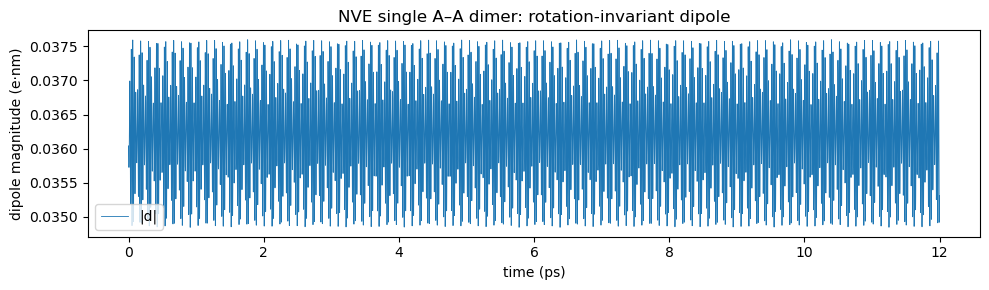

In [5]:
dipoles = []
for _ in range(N_steps):
    integrator.step(1)
    pos = context.getState(getPositions=True).getPositions(asNumpy=True).value_in_unit(unit.nanometer)
    dipoles.append(dipole_magnitude(pos, charges_single, [0, 1]))

dipoles = np.array(dipoles)
t_ps = np.arange(N_steps) * dt_ps

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(t_ps, dipoles, lw=0.6, label="|d|")
ax.set_xlabel("time (ps)")
ax.set_ylabel("dipole magnitude (e·nm)")
ax.set_title("NVE single A–A dimer: rotation-invariant dipole")
ax.legend()
plt.tight_layout()
plt.show()

Signal: 12000 points, duration = 12.00 ps


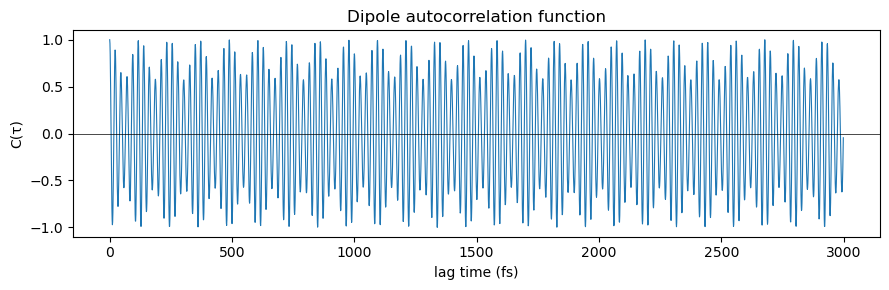

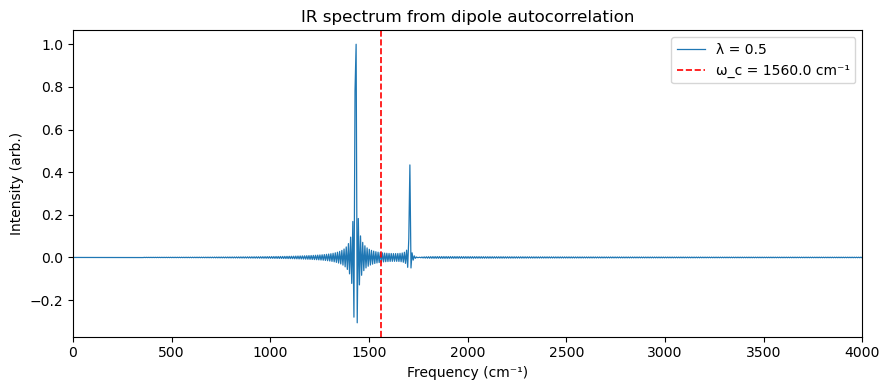

Peak frequency: 1435 cm⁻¹   (reference ω_c = 1560 cm⁻¹)


In [6]:
from scipy import fftpack, signal

fraction_acf = 0.25   # use first 25% of ACF (increase trajectory for tighter stats)
dipole_signal = dipoles.copy() - dipoles.mean()
N_sig = len(dipole_signal)
n_acf = max(3, int(N_sig * fraction_acf))
print(f"Signal: {N_sig} points, duration = {N_sig * dt_fs * 1e-3:.2f} ps")

# Unbiased autocorrelation (fftconvolve method)
if N_sig % 2 == 0:
    shifted = np.zeros(2 * N_sig)
else:
    shifted = np.zeros(2 * N_sig - 1)
shifted[N_sig // 2 : N_sig // 2 + N_sig] = dipole_signal
acf_full = signal.fftconvolve(shifted, dipole_signal[::-1], mode="same")[-N_sig:] / np.arange(N_sig, 0, -1)
autocorr = acf_full[:n_acf]

lag_fs = np.arange(n_acf) * dt_fs
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(lag_fs, autocorr / autocorr[0], lw=0.8)
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag time (fs)")
ax.set_ylabel("C(τ)")
ax.set_title("Dipole autocorrelation function")
plt.tight_layout()
plt.show()

# IR spectrum via DCT (linear response + quantum correction factor)
timestep = dt_fs * 1e-15
lineshape = fftpack.dct(autocorr, type=1)[1:]
freqs_hz = np.linspace(0, 0.5 / timestep, len(autocorr))[1:]
freqs_cm1 = freqs_hz / (100.0 * 299792458.0)

boltz = 1.38064852e-23
hbar = 1.05457180013e-34
field = freqs_hz * (1.0 - np.exp(-hbar * freqs_hz / (boltz * T_K)))
spectrum = lineshape * field

fig, ax = plt.subplots(figsize=(9, 4))
mask = (freqs_cm1 > 0) & (freqs_cm1 <= 4000)
if spectrum[mask].max() > 0:
    ax.plot(freqs_cm1[mask], spectrum[mask] / spectrum[mask].max(), lw=0.9, label=f"λ = {lambda_coupling}")
ax.axvline(OMEGA_C_CM1, color="r", ls="--", lw=1.2, label=f"ω_c = {OMEGA_C_CM1} cm⁻¹")
ax.set_xlim(0, 4000)
ax.set_xlabel("Frequency (cm⁻¹)")
ax.set_ylabel("Intensity (arb.)")
ax.set_title("IR spectrum from dipole autocorrelation")
ax.legend()
plt.tight_layout()
plt.show()

peak_mask = (freqs_cm1 > 500) & (freqs_cm1 < 3000)
if peak_mask.any() and spectrum[peak_mask].max() > 0:
    peak_cm1 = freqs_cm1[peak_mask][np.argmax(spectrum[peak_mask])]
else:
    peak_cm1 = freqs_cm1[1:][np.argmax(spectrum[1:])] if len(spectrum) > 1 else 0.0
print(f"Peak frequency: {peak_cm1:.0f} cm⁻¹   (reference ω_c = {OMEGA_C_CM1:.0f} cm⁻¹)")

## 6. Post-process the IR spectrum

Now apply the recipe from the theory section: autocorrelate $\mathbf{d}(t)$, FFT, and multiply by $\omega$.

### Expected results

- The dipole trace oscillates without damping; total energy is conserved in NVE.
- The spectrum peak should lie near 1560 cm⁻¹ (the mKA A–A stretch / cavity reference).
- Compare `lambda_coupling = 0.5` and `5.0`, and runs with versus without `displaceToEquilibrium()`, to see cavity coupling and finite-$q$ effects on the line.

**Next:** Tutorial 02 repeats this workflow under NVT with a Bussi–Parrinello thermostat.


---
## Reference: mKA constants

| Quantity | Symbol | Value |
|----------|--------|-------|
| Cavity frequency | ω_c | 1560 cm⁻¹ |
| A–A bond length | r₀ | 2.282 Bohr = 0.121 nm |
| A–A bond stiffness | K_AA | 0.732 Ha/Bohr² |
| Charge magnitude | q | ±0.3 e |
| A-atom mass | m_A | 16.0 amu |
| Photon mass | m_ph | 1/1822.9 amu |
